In [10]:
from resources.imports import *

from resources.lattices import calc_Kmatrix

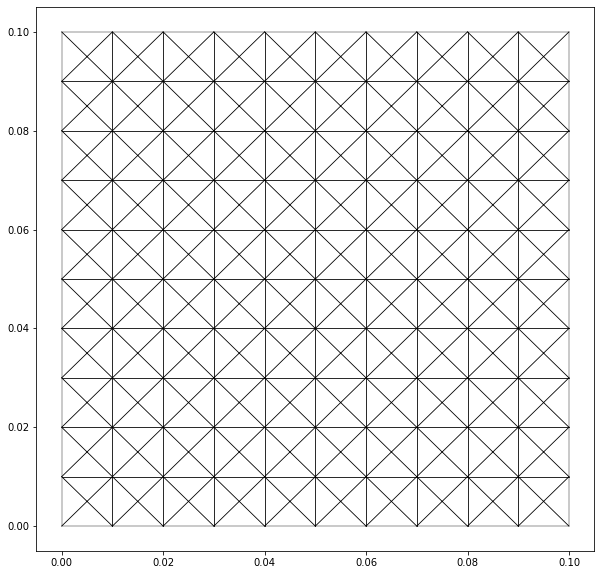

C:\Users\exy053\AppData\Local\Temp/ipykernel_38240/1712214614.py:8: RuntimeWarning: divide by zero encountered in double_scalars
  return np.array([np.cos(np.arctan([n0[1]/n0[0]]))[0], np.sin(np.arctan([n0[1]/n0[0]]))[0]])


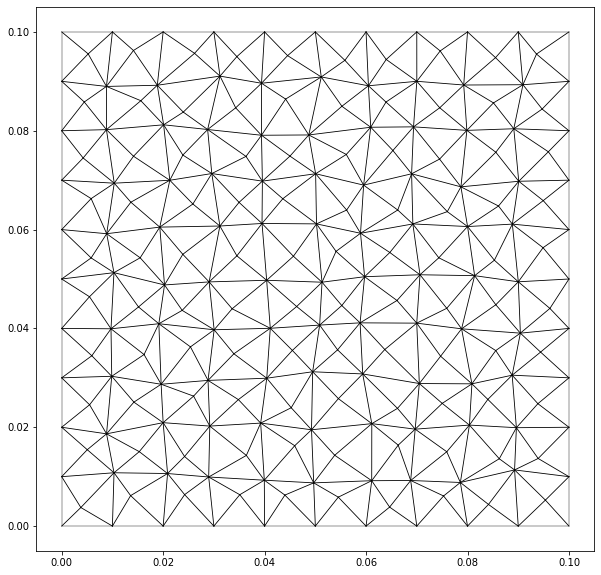

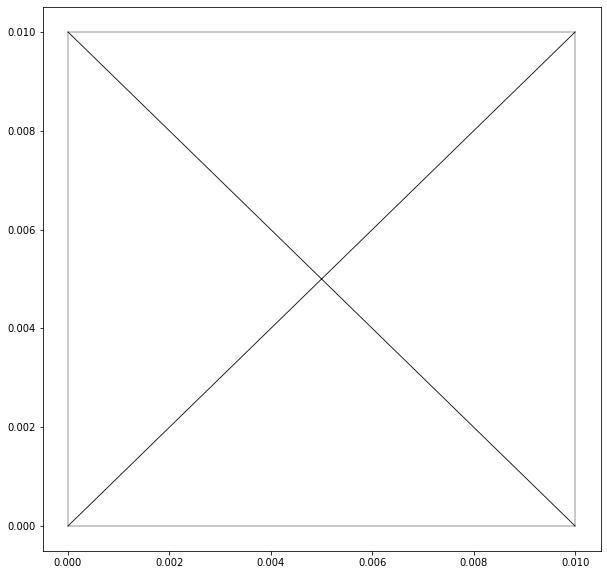

In [18]:
LAT = "FCC"
l = 0.01
nnx = 10
dis = 'dn'      # None, dn, ds

mode = "lattice"
Ks = calc_Kmatrix(LAT, l, nnx, mode, dis=dis, count=1, plot=True)

mode = "unit"
Kmatrix_unit = calc_Kmatrix(LAT, l, nnx, mode, plot=True)

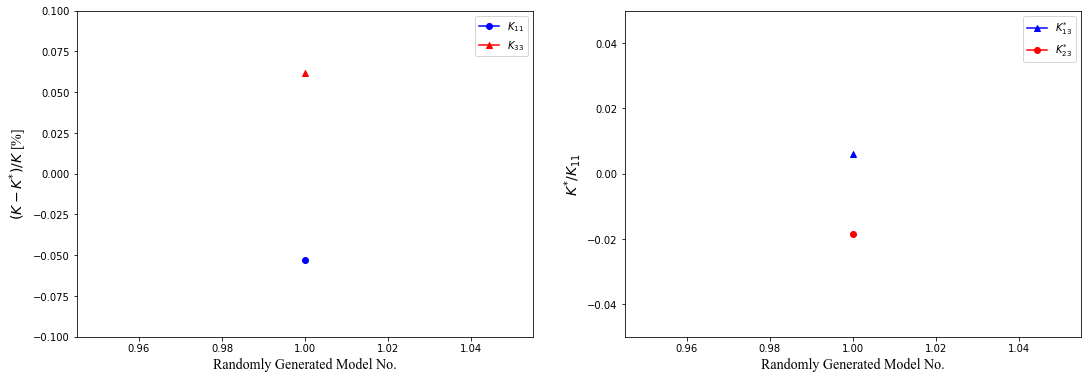

In [15]:
plot_IsotropyVariation(Ks)

In [16]:
def check_isotropy(K):
    if round(K[0][0]/K[0][1], 3) == 3.0 and round(K[0][0]/K[1][1], 3) == 1.0 and round(K[0][1]/K[2][2], 3) == 1.0:
        return True
    else:
        return False

def calc_effectiveProperties(K):
    iso = check_isotropy(K)
    v = 1/(K[0][0]/K[0][1]+1)
    E = (K[0][0]*((1+v)*(1-2*v)))/(1-v)
    return E, v, iso

E_eff, v_eff, iso = calc_effectiveProperties(Kmatrix_unit[0])
E_eff, v_eff, iso

(135661759.91249993, 0.2500000141666665, True)

In [17]:
v_iso = 0.25
K_iso_pStress = (1/(1-v_iso**2))*np.array([[1, v_iso, 0],
                                           [v_iso, 1, 0],
                                           [0, 0, (1-v_iso)/2]])
K_iso_pStrain = (1/((1-2*v_iso)*(1+v_iso)))*np.array([[1-v_iso, v_iso, 0],
                                                       [v_iso, 1-v_iso, 0],
                                                       [0, 0, (1-2*v_iso)/2]])

K_iso_pStress/min(K_iso_pStress[0][:2]), K_iso_pStrain/min(K_iso_pStrain[0][:2])

(array([[4. , 1. , 0. ],
        [1. , 4. , 0. ],
        [0. , 0. , 1.5]]),
 array([[3., 1., 0.],
        [1., 3., 0.],
        [0., 0., 1.]]))